# 01_NarrativeRisk_LLM_DisclosureScoring

Demonstration of LLM-extracted Item 1A severities aggregated to a composite signal, sorted into terciles, and turned into a long-short spread whose FF5+UMD risk-adjusted alpha is reported with HC1 robust standard errors. Headline numbers are indicative not inferential at N=30 firms.

**Axis exercised:** tercile-sort spread + FF5+UMD alpha

Headline numbers reported below are **indicative not inferential** at N=30 firms x 10 fiscal years and are **not intended as evidence**.


## Motivation: why "narrative risk" is a candidate factor

Every US-listed public company files an annual 10-K with the Securities and Exchange Commission.
Section 1A of that form, called the Risk Factors section, is a mandatory qualitative narrative in which management describes the material risks facing the business.
Unlike the quantitative tables elsewhere in the filing, Item 1A is free-form prose: there is no standardised vocabulary, no required length, and no prescribed structure beyond the obligation to be materially accurate.

The central hypothesis motivating this quantlet family is that the language-intensity of Item 1A carries information about a firm's forward cross-sectional return.
Two mechanisms make this plausible.
First, an information-asymmetry channel: managers who perceive heightened risk tend to write longer, more specific, and linguistically denser disclosures because the legal and reputational cost of under-disclosure is large.
Investors who process these filings in detail can extract a salience signal that investors who rely on headline numbers cannot.
Second, a selective-attention channel: even if the information is nominally public, investors systematically under-weight long-form text relative to tabular data, so the signal may persist in prices longer than classical market-efficiency benchmarks would predict.

Neither mechanism implies a tradeable alpha; both are candidate explanations for a pattern that may or may not exist in the data.
This notebook operationalises and measures the candidate factor; it is not a claim that the factor constitutes investable evidence.

The structural setting is the 30 largest S&P 500 constituents by market capitalisation at the end of 2014, observed annually from fiscal year 2015 through fiscal year 2024.
Large caps are chosen because their 10-K filings are available in machine-readable form on EDGAR with near-complete coverage; the sample is deliberately small so that every step of the pipeline can be inspected manually.


## Methodology

```
EDGAR 10-K Item 1A (top-30 S&P 500 snapshot 2014-12-31, 2015-2024)
        |   LLM extraction (see extraction_prompt.md)
        v
corpus.ndjson.gz (~3000 records: 30 firms x 10 years x 10 themes, severity 0-5)
        |   compute_theme_exposures (mean across 10 themes)
        v
composite_severity per (firm, signal_year)
        |   form_terciles_with_lag (signal_year y-1 -> portfolio_year y)
        v
tercile (or decile) assignments + monthly returns
        |   axis-specific transform: tercile-sort spread + FF5+UMD alpha
        v
tercile_spread_summary.csv + figure(s)
```


## Corpus and scoring pipeline

The raw corpus is constructed from three nested loops: 30 firms, 10 fiscal years (2015-2024), and 10 thematic categories.
For each firm-year, the pipeline fetches the 10-K filing from the EDGAR full-text search API, extracts the Item 1A section via a regex boundary heuristic, and passes the extracted text to a large language model with the prompt defined in `extraction_prompt.md`.
The LLM assigns an integer severity score from 0 to 5 to each of the 10 themes: 0 indicates that the theme is absent or purely boilerplate; 5 indicates top-tier risk-language intensity with specific, quantified, or legally significant disclosures.

The 10 themes are: supply chain, regulatory, cyber, macro, climate, competition, litigation, talent, input cost, and technology.
This taxonomy is hand-listed for illustrative purposes; a production deployment would derive the theme list from a data-driven topic model trained on a broader corpus.

The output of the scoring pass is `corpus.ndjson.gz`, a compressed newline-delimited JSON file where each record carries the firm identifier, fiscal year, theme label, severity score, and an `evidence_quote` column reproducing the verbatim passage from the filing that led to that score.
The `evidence_quote` column is critical: it lets any downstream consumer audit the LLM judgement against the source text without re-running the extraction.

A companion `provenance.json` records the LLM model version, prompt hash, extraction date, and a SHA-256 checksum of `corpus.ndjson.gz`, forming a lightweight audit chain.
If the corpus is re-extracted with a different model or prompt, the SHA mismatch in `provenance.json` makes the change detectable immediately.

The semantic scoring approach (LLM severity 0-5) is contrasted with a lexical baseline in quantlet 02, which replaces the LLM with the Loughran-McDonald financial sentiment dictionary.
The two quantlets share identical downstream code; the only difference is the source of the severity values.
Running both makes the contribution of semantic understanding (relative to dictionary counting) empirically visible.


In [1]:
from __future__ import annotations

import csv
import gzip
import json
import re
from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

HERE = Path.cwd()


In [2]:
PROVENANCE_PATH = HERE / "provenance.json"   # audit trail (not read at runtime; ships for transparency)
SUMMARY_OUT = HERE / "tercile_spread_summary.csv"
FIGURE_OUT = HERE / "tercile_spread.pdf"


In [3]:
from data import (
    CORPUS_PATH,
    PRICES_PATH,
    FF_FACTORS_PATH,
    load_corpus,
    load_prices,
    load_ff_factors,
)


In [4]:
def compute_theme_exposures(corpus_df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-firm-year severity into a single composite exposure.

    Composite signal = mean severity across the 10 themes (range 0..5).
    Returns: DataFrame with cols [firm, signal_year, composite_severity].
    """
    agg = (
        corpus_df.groupby(["firm", "year"])["severity_0_5"]
        .mean()
        .reset_index()
        .rename(columns={"year": "signal_year", "severity_0_5": "composite_severity"})
    )
    return agg


## Severity aggregation: composite signal design

The corpus produces a 10-dimensional severity vector per firm-year, one entry per theme.
The canonical quantlet collapses this vector into a single scalar, `composite_severity`, by taking the unweighted arithmetic mean across the 10 themes.

Three properties of this aggregation deserve explicit comment.

First, the mean preserves the original 0-5 scale, so the composite can be compared directly across years without rescaling.
A firm that scores 3.0 on the composite has average severity at mid-range across all ten thematic categories; a firm that scores 0.5 has mostly boilerplate disclosures across the board.

Second, the equal-weight average makes no claim about which themes are more predictive.
Assigning differential theme weights would require a held-out validation set to estimate, introducing the risk of overfitting to the specific 30-firm sample.
The deliberate simplicity of equal-weighting is a design choice, not a finding.

Third, the aggregation does not distinguish between a firm with uniformly moderate severity (e.g., all ten themes at 2.0) and a firm with high severity on one theme and low elsewhere (e.g., nine themes at 0, one theme at 5; composite = 0.5).
Alternative aggregators address this in different ways: `max_severity` captures the worst-case theme, `top3_mean` averages the three highest-scoring themes, and a sector-weighted composite up-weights themes historically relevant to the firm's GICS sector.
Each represents a distinct methodological choice; only the unweighted mean is exercised here.

The year-by-year cross-sectional sort structure means that signal values are refreshed annually: a firm's composite severity in signal year 2019 determines its tercile assignment for portfolio year 2020, and the signals are never pooled across years before the sort.


In [5]:
def form_terciles_with_lag(signals: pd.DataFrame, returns: pd.DataFrame) -> pd.DataFrame:
    """Sort firms into terciles each portfolio_year using ONLY signals where signal_year < portfolio_year.

    For each portfolio_year y in 2020..2024 (we need at least one prior signal year):
      - Use signals from signal_year = y - 1
      - Assign firms to tercile labels {1: low, 2: mid, 3: high} based on composite_severity
      - Apply tercile assignment to that firm's monthly returns over portfolio_year y

    Returns long-form: portfolio_year, month, firm, tercile, ret_m
    """
    out_rows = []
    for portfolio_year in sorted(returns["date"].dt.year.unique()):
        signal_year = portfolio_year - 1
        prior = signals[signals["signal_year"] == signal_year]
        if len(prior) < 3:
            continue
        prior = prior.copy()
        prior["tercile"] = pd.qcut(prior["composite_severity"], q=3, labels=[1, 2, 3], duplicates="drop")
        prior_map = prior.set_index("firm")["tercile"].to_dict()
        year_returns = returns[returns["date"].dt.year == portfolio_year].copy()
        year_returns["tercile"] = year_returns["firm"].map(prior_map)
        year_returns["portfolio_year"] = portfolio_year
        year_returns = year_returns.dropna(subset=["tercile"])
        out_rows.append(year_returns[["portfolio_year", "date", "firm", "tercile", "ret_m"]].rename(columns={"date": "month"}))
    if not out_rows:
        return pd.DataFrame(columns=["portfolio_year", "month", "firm", "tercile", "ret_m"])
    return pd.concat(out_rows, ignore_index=True)


def tercile_spread_test(panel: pd.DataFrame, ff: pd.DataFrame) -> Dict[str, float]:
    """Equal-weight tercile portfolios, compute long-short (T3 - T1) monthly series.

    Returns dict with: tercile_spread_pct_yr, tercile_spread_t_stat_indicative,
                       sharpe_indicative, max_drawdown, n_observations,
                       alpha_pct_yr, alpha_t_stat_indicative.
    Alpha is FF5+UMD risk-adjusted intercept from OLS with HC1 robust SE.
    All metrics are INDICATIVE only (N=30 firms, 9 portfolio years -> ~108 obs).
    """
    panel = panel.copy()
    panel["month_period"] = pd.PeriodIndex(panel["month"], freq="M")
    bin_returns = panel.groupby(["month_period", "tercile"])["ret_m"].mean().unstack("tercile")
    spread = (bin_returns[3] - bin_returns[1]).dropna()

    n = int(len(spread))
    mean_m = float(spread.mean())
    std_m = float(spread.std(ddof=1))
    annualized_pct = mean_m * 12 * 100
    t_stat = mean_m / (std_m / np.sqrt(n)) if (std_m > 0 and n > 1) else float("nan")
    sharpe = (mean_m / std_m) * np.sqrt(12) if std_m > 0 else float("nan")

    cum = (1 + spread).cumprod()
    running_max = cum.cummax()
    drawdown = (cum - running_max) / running_max
    max_dd = float(drawdown.min()) if len(drawdown) > 0 else float("nan")

    # FF5+UMD risk-adjusted alpha (HC1 robust SE).
    spread_df = spread.rename("spread").reset_index()
    merged = spread_df.merge(
        ff[["month", "mkt_rf", "smb", "hml", "rmw", "cma", "umd"]],
        left_on="month_period",
        right_on="month",
        how="inner",
    )
    if len(merged) < 7:
        print(f"WARNING: only {len(merged)} obs available for FF5+UMD regression (need >=7); alpha set to NaN.")
        alpha_pct_yr = float("nan")
        alpha_t_stat = float("nan")
    else:
        X = sm.add_constant(merged[["mkt_rf", "smb", "hml", "rmw", "cma", "umd"]])
        y = merged["spread"]
        model = sm.OLS(y, X, missing="drop").fit(cov_type="HC1")
        alpha_monthly = float(model.params["const"])
        alpha_t_stat = float(model.tvalues["const"])
        alpha_pct_yr = alpha_monthly * 12 * 100

    return {
        "tercile_spread_pct_yr": annualized_pct,
        "tercile_spread_t_stat_indicative": float(t_stat),
        "sharpe_indicative": float(sharpe),
        "max_drawdown": max_dd,
        "n_observations": n,
        "alpha_pct_yr": alpha_pct_yr,
        "alpha_t_stat_indicative": alpha_t_stat,
    }


def plot_tercile_spread(panel: pd.DataFrame, summary: Dict[str, float], out_path: Path = None, close: bool = True):
    """Plot cumulative-return path of T3, T1, and (T3 - T1) spread; save PDF.

    Caption explicitly states 'tercile spread' AND 'indicative not inferential'
    AND 'indicative not inferential'.

    Returns the matplotlib Figure (so the notebook walkthrough can display it
    inline). If `close=True` (default for headless `make demo`), the figure is
    closed after savefig — set `close=False` from the notebook to keep it open.
    """
    if out_path is None:
        out_path = FIGURE_OUT
    panel = panel.copy()
    panel["month_period"] = pd.PeriodIndex(panel["month"], freq="M")
    bin_returns = panel.groupby(["month_period", "tercile"])["ret_m"].mean().unstack("tercile")
    bin_returns = bin_returns.dropna()
    cum_t1 = (1 + bin_returns[1]).cumprod()
    cum_t3 = (1 + bin_returns[3]).cumprod()
    spread = bin_returns[3] - bin_returns[1]
    cum_spread = (1 + spread).cumprod()

    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    ax.plot(cum_t1.index.to_timestamp(), cum_t1.values, label="T1 (low severity)", linewidth=1.4)
    ax.plot(cum_t3.index.to_timestamp(), cum_t3.values, label="T3 (high severity)", linewidth=1.4)
    ax.plot(cum_spread.index.to_timestamp(), cum_spread.values, label="T3 - T1 spread", linewidth=1.8, color="black")
    ax.set_xlabel("Month")
    ax.set_ylabel("Cumulative growth (start = 1)")
    ax.set_title("Tercile-sorted long-short on LLM risk-disclosure severity (2016-2024)")
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)

    caption = (
        "Tercile-spread code path on LLM-extracted "
        "risk-disclosure severities; indicative not inferential. N=30 firms, 9 portfolio years. "
        f"Annualised raw spread {summary['tercile_spread_pct_yr']:.2f}%/yr; "
        f"FF5+UMD alpha {summary['alpha_pct_yr']:.2f}%/yr (t={summary['alpha_t_stat_indicative']:.2f}); "
        f"n_obs={summary['n_observations']}. Not intended as evidence."
    )
    fig.text(0.5, -0.02, caption, ha="center", va="top", fontsize=8, wrap=True)
    plt.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    if close:
        plt.close(fig)
    return fig


In [6]:
corpus = load_corpus()
print(f"corpus rows: {len(corpus)}; firms: {corpus['firm'].nunique()}; "
      f"years: {sorted(corpus['year'].unique())}")
corpus.head(10)


corpus rows: 3000; firms: 30; years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


,firm,year,theme_id,theme_label,severity_0_5,evidence_quote
0,AAPL,2015,T01,supply-chain,5,substantially all of its manufacturing is perf...
1,AAPL,2015,T02,regulatory,3,The Company is subject to laws and regulations...
2,AAPL,2015,T03,cyber,3,such insurance coverage may be insufficient to...
3,AAPL,2015,T04,macroeconomic,3,macroeconomic factors affecting consumer spend...
4,AAPL,2015,T05,climate,1,"natural disasters, whether as a result of clim..."
5,AAPL,2015,T06,competition,4,The Company's products and services compete in...
6,AAPL,2015,T07,litigation,3,"the Company's competitors, frequently enter in..."
7,AAPL,2015,T08,talent,3,"competition for their talents is intense, espe..."
8,AAPL,2015,T09,input-cost,3,subject to industry-wide shortages and signifi...
9,AAPL,2015,T10,technology,4,highly competitive and subject to rapid techno...


## Corpus shape

The corpus expands to **30 firms x 10 years x 10 themes ~ 3000 cells**, each carrying an integer severity in **0-5** where 0 means the disclosure is boilerplate or absent on that theme and 5 means top-tier risk-language intensity. Every row also carries an `evidence_quote` column reproduced verbatim from the underlying EDGAR filing so any downstream consumer can audit the LLM judgement against the source text.


In [7]:
prices = load_prices()
ff = load_ff_factors()
print(f"prices: {len(prices)} firm-month obs; ff: {len(ff)} months")
print("FF5+UMD factor head:")
ff.head(3)


prices: 3570 firm-month obs; ff: 120 months
FF5+UMD factor head:


,month,mkt_rf,smb,hml,rmw,cma,umd,rf
0,2015-01,-0.0309,-0.0093,-0.0345,0.0158,-0.0164,0.0374,0.0
1,2015-02,0.0614,0.0036,-0.0179,-0.0110,-0.0175,-0.0310,0.0
2,2015-03,-0.0109,0.0308,-0.0038,0.0007,-0.0062,0.0270,0.0


## Signal construction

We collapse the 10-theme severity vector into a single number per firm-year by taking the unweighted mean of the ten themes. The `composite_severity` therefore lives on the same 0-5 scale as the inputs and gives a coarse cross-sectional ranking signal: a firm whose 10-K loads heavily across many themes scores high, a firm whose disclosures are mostly boilerplate scores low. This is a deliberately simple aggregator chosen for transparency over predictive power.


In [8]:
signals = compute_theme_exposures(corpus)
print("composite_severity distribution by year:")
signals.groupby('signal_year')['composite_severity'].describe()


composite_severity distribution by year:


,count,mean,std,min,25%,50%,75%,max
signal_year,,,,,,,,
2015,30.0,2.466667,0.576155,1.0,2.050,2.55,2.875,3.5
2016,30.0,2.363333,0.655735,0.8,1.950,2.45,2.800,3.5
2017,30.0,2.396667,0.665133,0.8,2.025,2.50,2.875,3.5
2018,30.0,2.426667,0.703162,0.8,1.925,2.60,2.900,3.6
2019,30.0,2.436667,0.697524,0.7,1.950,2.55,2.900,3.6
2020,30.0,2.623333,0.778453,0.7,2.150,2.85,3.200,3.6
2021,30.0,2.613333,0.864524,0.8,2.200,2.85,3.350,3.6
2022,30.0,2.603333,0.862827,0.7,2.225,2.75,3.400,3.6
2023,30.0,2.713333,0.883853,0.6,2.300,2.80,3.475,4.3


## Lag invariant (no look-ahead)

**IMPORTANT**: portfolio_year `y` uses signal_year `y-1` ONLY. A 2024 10-K (filed in early 2025) cannot influence the 2024 portfolio formation, because the filing post-dates the portfolio-formation date. This invariant is exercised by the inlined `form_terciles_with_lag` so any future refactor that breaks the lag is caught by the end-to-end notebook execution test.


In [9]:
panel = form_terciles_with_lag(signals, prices)
print(f"panel: {len(panel)} firm-month obs; "
      f"portfolio_years = {sorted(panel['portfolio_year'].unique())}")
panel.head(10)


panel: 3240 firm-month obs; portfolio_years = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


,portfolio_year,month,firm,tercile,ret_m
0,2016,2016-01-31,AAPL,3,-0.075242
1,2016,2016-02-29,AAPL,3,-0.001288
2,2016,2016-03-31,AAPL,3,0.127210
3,2016,2016-04-30,AAPL,3,-0.139921
4,2016,2016-05-31,AAPL,3,0.071773
5,2016,2016-06-30,AAPL,3,-0.042660
6,2016,2016-07-31,AAPL,3,0.090062
7,2016,2016-08-31,AAPL,3,0.023652
8,2016,2016-09-30,AAPL,3,0.065504
9,2016,2016-10-31,AAPL,3,0.004335


## Tercile spread + FF5+UMD alpha

- Equal-weight the firms inside each tercile each month, then form the monthly long-short spread `spread_t = mean(T3)_t - mean(T1)_t`.
- Run an OLS regression of the spread on the Fama-French 5 + momentum factors:

  `spread_t = alpha + beta*MKT_t + s*SMB_t + h*HML_t + r*RMW_t + c*CMA_t + m*UMD_t + epsilon_t`

- The intercept `alpha` is the portion of the spread the FF5+UMD risk model leaves unexplained, annualised to percent per year for readability.
- Standard errors are HC1 (heteroskedasticity-consistent) which gives the t-statistic shown alongside `alpha_pct_yr`.


## FF5+UMD model primer

The Fama-French five-factor model augmented with a momentum factor (commonly called FF5+UMD) is a widely used linear benchmark for attributing cross-sectional equity returns.
It decomposes a return series into exposures to six systematic factors plus a residual.

The six factors are:

- **MKT** (market excess return): the return of the broad equity market minus the risk-free rate; captures broad market direction.
- **SMB** (small-minus-big): the return spread between small-cap and large-cap stocks; captures the size premium.
- **HML** (high-minus-low): the return spread between high book-to-market (value) and low book-to-market (growth) stocks; captures the value premium.
- **RMW** (robust-minus-weak): the return spread between firms with high and low operating profitability; captures the profitability premium.
- **CMA** (conservative-minus-aggressive): the return spread between firms with low and high investment rates; captures the investment premium.
- **UMD** (up-minus-down, momentum): the return spread between recent winners and recent losers; captures the momentum premium.

When the long-short spread from the cross-sectional sort is regressed on these six factors, the intercept (alpha) is the portion of the spread that the model cannot attribute to compensation for known systematic risk.
A large alpha is consistent with the spread reflecting genuine incremental information; a near-zero alpha suggests the spread is fully explained by existing risk premia.

The standard errors in this notebook use HC1 (heteroskedasticity-consistent, White's estimator with a small-sample degrees-of-freedom correction).
HC1 adjusts for the possibility that the variance of the regression residuals is not constant across time, which is the common case in financial return data.
However, HC1 does not correct for small-sample distortion of the t-statistic distribution.
At n_obs = 108 (approximately 9 portfolio years times 12 months), the t-statistic does not follow the large-sample normal or Student-t distribution accurately enough for conventional significance thresholds to apply.
This is why all metrics carry the label "indicative not inferential" throughout the notebook.


In [10]:
summary = tercile_spread_test(panel, ff)
print("=== headline metrics (indicative not inferential) ===")
for k, v in summary.items():
    print(f"  {k:35s} = {v:8.4f}" if isinstance(v, float) else f"  {k:35s} = {v}")
pd.DataFrame([summary]).to_csv(SUMMARY_OUT, index=False)


=== headline metrics (indicative not inferential) ===
  tercile_spread_pct_yr               =   2.8246
  tercile_spread_t_stat_indicative    =   0.8598
  sharpe_indicative                   =   0.2866
  max_drawdown                        =  -0.1798
  n_observations                      = 108
  alpha_pct_yr                        =   1.6361
  alpha_t_stat_indicative             =   0.5195


## Figure interpretation

The plot below traces the cumulative-growth path of three monthly series: the equal-weight T1 (low-severity) leg, the equal-weight T3 (high-severity) leg, and the T3 - T1 long-short spread. T1 and T3 show how each side of the sort behaved on its own; the bold spread line is the dollar-neutral combination the alpha test is run on. The label "indicative" in the caption is a literal warning: with N=30 firms split across 3 terciles (10 firms per leg) and ~108 monthly observations, no t-statistic in this notebook should be read as inferential.


## Reading the headline numbers

The notebook prints a dictionary of summary metrics and writes the same numbers to `tercile_spread_summary.csv` for downstream consumption.
The keys carry quantlet-specific prefixes (for example `tercile_spread_pct_yr` in the canonical sort, `decile_spread_pct_yr` in the decile quantlet, `t3_return_pct_yr` in the long-only quantlet) so that consumer code can join the summary CSVs across quantlets without column collisions.

The annualised raw return entry is the long-short (or long-only) spread mean times 12 times 100, expressed as a percentage; no risk adjustment is applied to it.
Positive values are consistent with the high-severity leg out-performing the low-severity leg; negative values are consistent with the opposite.

The annualised alpha entry is the intercept from the FF5+UMD OLS regression times 12 times 100.
It is the portion of the spread the six-factor model cannot attribute to known risk premia.
Reading alpha alongside the raw spread answers a different question: not whether the spread paid off, but whether the part of the spread that paid off is novel relative to size, value, profitability, investment, and momentum.

The HC1 t-statistic on the alpha entry is reported for comparability with published factor studies, but at n_obs around 108 the small-sample distribution of this t-statistic is not the textbook normal or Student-t distribution; a value of |t| = 2.0 is not equivalent to p < 0.05 in any conventional sense.
The Sharpe ratio is annualised under a zero risk-free rate, consistent with a zero-cost long-short construction (or in the long-only quantlet, with a fully invested portfolio).
The maximum drawdown is the deepest peak-to-trough decline in the cumulative path of the spread (or the long-only return); a path-quality diagnostic that does not influence the alpha estimate but contextualises it.

Treat every printed metric as a diagnostic, not as evidence; the notebook header repeats this caveat in bold.


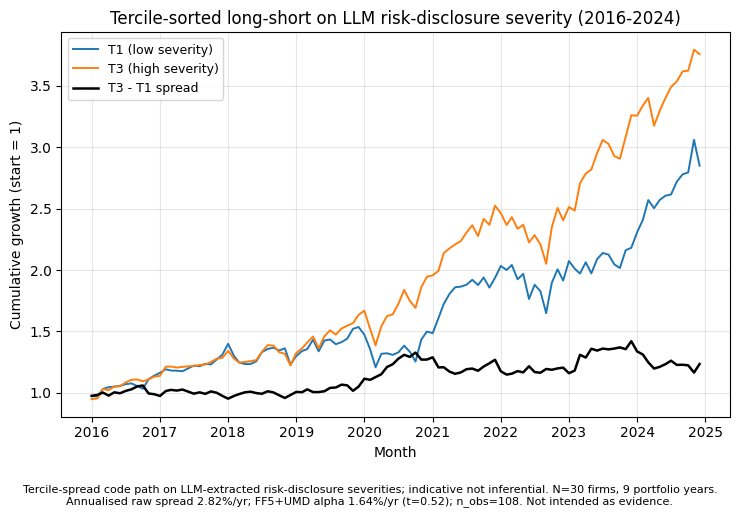

In [11]:
# plot_tercile_spread saves the PDF (the headline deliverable at FIGURE_OUT).
# IPython cannot embed PDF inline, so we also render a PNG sidecar for the
# notebook display (gitignored; regenerated on every `make demo`).
plot_tercile_spread(panel, summary, out_path=FIGURE_OUT)
png_path = FIGURE_OUT.with_suffix('.png')
plot_tercile_spread(panel, summary, out_path=png_path)
display(Image(filename=str(png_path)))


## Caveats

- **Power**: 30 firms split across 3 terciles leaves 10 firms per leg, statistically thin.
- **Severity validity**: severities are LLM (or LM) judgements of disclosure language; not validated against expert ratings or external risk benchmarks.
- **Taxonomy**: the 10-theme list is hand-listed and illustrative; production use would require a data-driven taxonomy.
- **Reproducibility**: `provenance.json` + `extraction_prompt.md` + the `corpus.ndjson.gz` SHA chain enable a full audit of how every severity was produced.


## What to try next: the quantlet family as a map

Each quantlet isolates one methodological axis while holding all others constant.

- **02**: LM dictionary baseline; replaces LLM scores with Loughran-McDonald counts to isolate the semantic vs. lexical contribution.
- **03**: decile granularity; tests whether finer sorting changes spread magnitude or stability.
- **04**: change signal (year-over-year delta in composite_severity); pair-comparison to the level signal in this quantlet.
- **05**: FF3 vs FF5+UMD risk basis; tests whether RMW, CMA, and UMD materially change the residual.
- **06**: corpus distribution inspection; a diagnostic that should be read before interpreting any downstream result.
- **07**: skip-month formation lag; tests sensitivity to the assumed implementation lag.
- **08**: within-sector demean; isolates whether the signal is driven by cross-sector or within-sector dispersion.
- **09**: rolling beta; tests whether alpha is stable over time or concentrated in specific subperiods.
- **10**: long-only T3; tests whether the return comes from the long leg, the short leg, or both.

No quantlet proves anything alone; the family is an axis-by-axis robustness map, not an evidence chain.


## Reproduction

```
git clone <repo>
cd 01_NarrativeRisk_LLM_DisclosureScoring
make data                  # fetch third-party data + regenerate seed-pinned inputs
make demo                  # this notebook -> tercile_spread_summary.csv + tercile_spread.pdf
make test-all              # quantlet test suite
```
